In [31]:
import sys

sys.path.append("../")

In [32]:
import pandas as pd
from token_library.vocab import VOCAB, ALL_VALID_TOKENS, ALLOWED_PUNCTUATION, PRR_HAS_CONTOUR
emmanuel_calls_df = pd.read_csv("../data/ford-catalogue/emmanuel_online_catalogue_annotated_parsed.csv")
maddie_calls_df = pd.read_csv("../data/ford-catalogue/maddie_online_catalogue_annotated_parsed.csv")

# For all rows, keep those that are Annotated == False from emmanuel and Annotated == True from Maddie,
# but if a Maddie filename is Annotated == True, move any matching Emmanuel row (by filename) into Emmanuel (overwrite if exists).
# So: first keep all Emmanuel rows, but for any Maddie row with Annotated == True, replace Emmanuel's by Maddie's.

# First, index both by filename for easy replacement
emmanuel_calls_df_indexed = emmanuel_calls_df.set_index("filename")
maddie_true = maddie_calls_df[maddie_calls_df["Annotated"] == True].set_index("filename")

# Update emmanuel's rows with Maddie's Annotated==True rows (by filename)
emmanuel_calls_df_indexed.update(maddie_true)

# Now get a merged dataframe, but add any Maddie (Annotated==True) filenames that are NOT present in Emmanuel
new_maddie_rows = maddie_true[~maddie_true.index.isin(emmanuel_calls_df_indexed.index)]
calls_df = pd.concat([emmanuel_calls_df_indexed, new_maddie_rows]).reset_index()


/var/folders/j5/prvccmy93sn3187zg4qcc1_40000gn/T/ipykernel_13535/2186282740.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False 'FALSE' False 'FALSE' False 'FALSE' False 'FALSE' False 'FALSE'
 'FALSE' 'FALSE' False 'FALSE' False False 'FALSE' False 'FALSE' False
 'FALSE' False False 'FALSE' False False False 'FALSE' 'FALSE' 'FALSE'
 False 'FALSE' False False 'FALSE' 'FALSE' False 'FALSE' 'FALSE' False
 False False 'FALSE' 'FALSE' 'FALSE' False False False 'FALSE' False False
 False False 'FALSE' 'FALSE' 'FALSE' False 'FALSE' False 'FALSE' False
 'FALSE' False 'FALSE' 'FALSE' False False False False 'FALSE' 'FALSE'
 'FALSE' False 'FALSE' False 'FALSE' False 'FALSE' False 'FALSE' 'FALSE'
 False False False 'FALSE' False 'FALSE' 'FALSE' False 'FALSE' False False
 'FALSE' False False 'FALSE' 'FALSE' False False False 'FALSE' 'FALSE'
 'FALSE' False False 'FALSE' False False 'FALSE' False False 'FALSE'
 'FALSE' F

In [33]:
calls_df.to_csv("../data/ford-catalogue/merged_online_catalogue_annotated_parsed.csv", index=False)

In [34]:
calls_df["Annotated"].value_counts()


Annotated
True     119
False     83
Name: count, dtype: int64

In [35]:
pd.set_option('display.max_columns', None)
calls_df

,filename,call_type,clan,pod,audio_fp,spect_fp,call_number,annotator,annotated,raw_labels_txt,P1_start,P1_end,P1,P2_start,P2_end,P2,P3_start,P3_end,P3,P4_start,P4_end,P4,P5_start,P5_end,P5,BIPHO_start,BIPHO_end,BIPHO,EXTRA_start,EXTRA_end,EXTRA,note,PEAK_max,VALLEY_min,BIPHO_PEAK_max,BIPHO_VALLEY_min,Annotated,Both annotated
0,N01i-A1-1,N01i,A,A1,data/ford-catalogue/Northern Resident/media/A_...,data/ford-catalogue/spects/N01i-A1-1.png,N01,emmanuel,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
1,N01i-A1-2,N01i,A,A1,data/ford-catalogue/Northern Resident/media/A_...,data/ford-catalogue/spects/N01i-A1-2.png,N01,maddie,FALSE,0.186964\t0.385861\tP1: TIGHT FLAT\n0.385861\t...,0.186964,0.385861,TIGHT FLAT,0.385861,0.525090,"NORMAL FLAT, TIGHT VALLEY",0.525090,1.527533,"PEAK, UP SLOW, PEAK",NaN,NaN,NaN,NaN,NaN,NaN,0.437575,0.763767,UP FLAT,NaN,NaN,NaN,NaN,1.466692,0.492125,NaN,NaN,True,NaN
2,N01i-A1-3,N01i,A,A1,data/ford-catalogue/Northern Resident/media/A_...,data/ford-catalogue/spects/N01i-A1-3.png,N01,emmanuel,False,0.000000\t0.066844\tNote: P2 is very unclear\n...,0.378784,0.574542,BLUR,0.574542,0.697090,TIGHT FLAT ?,0.682766,1.941666,"PEAK, FLAT",NaN,NaN,NaN,NaN,NaN,NaN,0.574542,1.917793,"UP, FLAT, DOWN FAST SHORT",NaN,NaN,NaN,P2 is very unclear,0.757568,NaN,NaN,NaN,True,NaN
3,N01i-A1-4,N01i,A,A1,data/ford-catalogue/Northern Resident/media/A_...,data/ford-catalogue/spects/N01i-A1-4.png,N01,maddie,FALSE,0.102733\t0.102733\tNOTE: lots of background n...,0.232340,0.433123,TIGHT FLAT,0.433123,0.559038,FLAT NORMAL,0.559038,1.661644,"PEAK, UP SLOW, PEAK",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lots of background noise,1.567615,NaN,NaN,NaN,True,NaN
4,N01ii-B1-1,N01ii,A,B1,data/ford-catalogue/Northern Resident/media/A_...,data/ford-catalogue/spects/N01ii-B1-1.png,N01,emmanuel,False,0.236344\t0.467889\tP1: VERTICAL\n0.467889\t1....,0.236344,0.467889,VERTICAL,0.467889,0.503880,GAP,0.503880,1.325685,"PEAK, FLAT",NaN,NaN,NaN,NaN,NaN,NaN,0.467889,1.278897,"UP FAST SHORT, PEAK, DOWN SLOW",NaN,NaN,NaN,NaN,0.572264,NaN,0.63105,NaN,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,N51-R1-1,N51,R,R1,data/ford-catalogue/Northern Resident/media/R_...,data/ford-catalogue/spects/N51-R1-1.png,N51,emmanuel,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
198,N51-R1-2,N51,R,R1,data/ford-catalogue/Northern Resident/media/R_...,data/ford-catalogue/spects/N51-R1-2.png,N51,maddie,FALSE,"0.153993\t0.781096\tP1: TIGHT UP SLOW, TIGHT U...",0.153993,0.781096,"TIGHT UP SLOW, TIGHT UP FAST",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN
199,N52-R1-1,N52,R,R1,data/ford-catalogue/Northern Resident/media/R_...,data/ford-catalogue/spects/N52-R1-1.png,N52,emmanuel,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
200,N53-R1-1,N53,R,R1,data/ford-catalogue/Northern Resident/media/R_...,data/ford-catalogue/spects/N53-R1-1.png,N53,emmanuel,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN


## Preprocessing: Explode to unit-level (subpart) dataframe

In [36]:
def classify_tokens(unit_str):
    """
    Given a single unit string (e.g. "UP T SHORT FAST"),
    classify each token into its vocabulary category.
    Returns a dict with keys: prr, contour (singular), modifiers, specials, uncertain, is_transition.
    Raises ValueError on multiple PRRs, multiple contours, or invalid PRR+contour combo.
    """
    result = {
        'prr': None,
        'contour': None,
        'modifiers': [],
        'specials': [],
        'uncertain': False,
        'is_transition': False,
        'is_gap': False,
    }

    prr_found = []
    contour_found = []

    raw_tokens = unit_str.strip().split()
    for token in raw_tokens:
        t = token.upper().strip()

        if t in ALLOWED_PUNCTUATION:
            if t == '?':
                result['uncertain'] = True
            continue

        if t.endswith('?'):
            result['uncertain'] = True
            t = t.rstrip('?')

        if not t:
            continue

        if t in VOCAB['prr']:
            prr_found.append(t)
        elif t in VOCAB['contour']:
            contour_found.append(t)
        elif t in VOCAB['modifier']:
            result['modifiers'].append(t)
        elif t in VOCAB['special']:
            result['specials'].append(t)

    # --- Validate PRR: exactly 0 or 1 ---
    if len(prr_found) > 1:
        raise ValueError(f"Multiple PRR tokens: {prr_found}")
    result['prr'] = prr_found[0] if prr_found else None

    # --- SQUIGGLE special case: UP/DOWN become modifiers ---
    if 'SQUIGGLE' in contour_found:
        for ct in contour_found:
            if ct in ('UP', 'DOWN'):
                result['modifiers'].append(ct)
        contour_found = [c for c in contour_found if c not in ('UP', 'DOWN')]

    # --- Validate contour: exactly 0 or 1 ---
    if len(contour_found) > 1:
        raise ValueError(f"Multiple contour tokens: {contour_found}")
    result['contour'] = contour_found[0] if contour_found else None

    # --- T is a modifier → derive is_transition ---
    if 'T' in result['modifiers']:
        result['is_transition'] = True

    if 'GAP' in result['specials']:
        result['is_gap'] = True

    # --- Implicit NORMAL PRR (unless GAP) ---
    if result['prr'] is None and 'GAP' not in result['specials']:
        result['prr'] = 'NORMAL'

    # --- PRRs that can't have contours → auto NONE ---
    if result['prr'] is not None and result['prr'] not in PRR_HAS_CONTOUR:
        if result['contour'] is not None and result['contour'] != 'NONE':
            raise ValueError(f"PRR '{result['prr']}' cannot have contour '{result['contour']}'")
        result['contour'] = 'NONE'
    # --- PRRs that require contours but none given ---
    if result['prr'] in PRR_HAS_CONTOUR:
        if result['contour'] is None:
            raise ValueError(f"PRR '{result['prr']}' should have a contour, but none was found.")

    return result

print(classify_tokens("UP T SHORT FAST"))
print(classify_tokens("SQUIGGLE UP"))
print(classify_tokens("BLUR"))
print(classify_tokens("GAP"))


{'prr': 'NORMAL', 'contour': 'UP', 'modifiers': ['T', 'SHORT', 'FAST'], 'specials': [], 'uncertain': False, 'is_transition': True, 'is_gap': False}
{'prr': 'NORMAL', 'contour': 'SQUIGGLE', 'modifiers': ['UP'], 'specials': [], 'uncertain': False, 'is_transition': False, 'is_gap': False}
{'prr': 'BLUR', 'contour': 'NONE', 'modifiers': [], 'specials': [], 'uncertain': False, 'is_transition': False, 'is_gap': False}
{'prr': None, 'contour': None, 'modifiers': [], 'specials': ['GAP'], 'uncertain': False, 'is_transition': False, 'is_gap': True}


In [37]:

def explode_to_units(df):
    """
    Explode the call-level dataframe into a unit-level (subpart) dataframe.
    Each row = one comma-separated unit within a part.
    """
    rows = []
    bad_filenames = set()
    
    part_cols = [f'P{i}' for i in range(1, 6)] + ['BIPHO', 'EXTRA']
    
    for idx in df[df['Annotated'] == True].index:
        row = df.loc[idx]
        call_unit_counter = 0
        call_rows = []
        call_valid = True
        
        for part in part_cols:
            content = row.get(part)
            if pd.isna(content) or not content:
                continue
            
            part_start = row.get(f'{part}_start')
            part_end = row.get(f'{part}_end')
            part_duration = None
            if pd.notna(part_start) and pd.notna(part_end):
                part_duration = float(part_end) - float(part_start)
            
            # First split by | to get alternatives (each redefines all units)
            alternatives = [a.strip() for a in str(content).split('|')]
            
            # Max units across alternatives — next part starts after this
            max_units_in_part = max(
                len([u for u in alt.split(',') if u.strip()])
                for alt in alternatives
            )
            
            for alt_idx, alt_str in enumerate(alternatives):
                # Then split by , to get units within this alternative
                units = [u.strip() for u in alt_str.split(',')]
                n_units = len(units)
                
                for unit_idx, unit_str in enumerate(units):
                    if not unit_str:
                        continue
                    
                    try:
                        classified = classify_tokens(unit_str)
                    except ValueError as e:
                        print(f"  ERROR in {row['filename']} / {part}: {e}  →  removing call")
                        call_valid = False
                        break

                    unit_row = {
                        # Call-level info
                        'filename': row['filename'],
                        'call_type': row['call_type'],
                        'call_number': row.get('call_number'),
                        'clan': row.get('clan'),
                        'pod': row.get('pod'),

                        # Part-level info
                        'part': part,
                        'part_start': part_start,
                        'part_end': part_end,
                        'part_duration': part_duration,
                        'part_is_short': part_duration is not None and part_duration < 0.1,
                        'part_alternative': alt_idx,

                        # Unit-level info
                        'part_unit_idx': unit_idx + 1,
                        'call_unit_idx': call_unit_counter + unit_idx + 1,
                        'n_units': n_units,

                        'raw_unit': unit_str,

                        # Classified tokens
                        'prr': classified['prr'],
                        'contour': classified['contour'],
                        'modifiers': ', '.join(classified['modifiers']) if classified['modifiers'] else None,
                        'specials': ', '.join(classified['specials']) if classified['specials'] else None,
                        'uncertain': classified['uncertain'],
                        'is_transition': classified['is_transition'],
                        'is_gap': classified['is_gap'],
                        

                        'modifier_list': classified['modifiers'],
                        'special_list': classified['specials'],

                        'note': row.get('note'),
                    }

                    # Implicit SHORT: if part duration < 0.1s
                    if unit_row['part_is_short'] and 'SHORT' not in (classified['modifiers'] or []):
                        if classified['modifiers']:
                            unit_row['modifiers'] += ', SHORT'
                        else:
                            unit_row['modifiers'] = 'SHORT'
                        unit_row['modifier_list'] = unit_row['modifier_list'] + ['SHORT']

                    # Derived columns
                    prr = unit_row['prr']
                    contour = unit_row['contour']
                    mods = sorted(unit_row['modifier_list'])

                    if unit_row['is_gap']:
                        unit_row['prr_contour'] = 'GAP'
                        unit_row['contour_modified'] = 'GAP'
                        unit_row['prr_contour_modified'] = 'GAP'
                    else:
                        unit_row['prr_contour'] = '_'.join(filter(None, [prr, contour]))
                        unit_row['contour_modified'] = '_'.join(filter(None, [contour] + mods)) or None
                        unit_row['prr_contour_modified'] = '_'.join(filter(None, [prr, contour] + mods)) or None

                    

                    call_rows.append(unit_row)

                if not call_valid:
                    break
            if not call_valid:
                break

            # Advance call-level counter by max units across alternatives
            call_unit_counter += max_units_in_part

        if call_valid:
            rows.extend(call_rows)
        else:
            bad_filenames.add(row['filename'])

    if bad_filenames:
        print(f"\nRemoved {len(bad_filenames)} calls with errors: {sorted(bad_filenames)}")

    units_df = pd.DataFrame(rows)
    return units_df


units_df = explode_to_units(calls_df)
print(f"Created units_df: {len(units_df)} unit rows from {units_df['filename'].nunique()} calls")
print(f"\nParts distribution:")
print(units_df['part'].value_counts().to_string())
print(f"\nPRR distribution (with implicit NORMAL):")
print(units_df['prr'].value_counts().to_string())

  ERROR in N01i-A1-2 / BIPHO: Multiple contour tokens: ['UP', 'FLAT']  →  removing call
  ERROR in N01v-A4-1 / BIPHO: Multiple contour tokens: ['UP', 'FLAT']  →  removing call
  ERROR in N02-A5-2 / BIPHO: Multiple contour tokens: ['VALLEY', 'FLAT']  →  removing call
  ERROR in N05i-H1-2 / EXTRA: PRR 'NORMAL' should have a contour, but none was found.  →  removing call
  ERROR in N05ii-B1-1 / P4: PRR 'TIGHT' should have a contour, but none was found.  →  removing call
  ERROR in N08i-A1-1 / P1: PRR 'VERTICAL' cannot have contour 'UP'  →  removing call
  ERROR in N08i-H1-1 / P1: PRR 'VERTICAL' cannot have contour 'UP'  →  removing call
  ERROR in N08ii-D1-1 / P1: PRR 'VERTICAL' cannot have contour 'UP'  →  removing call
  ERROR in N08iii-I2-1 / P1: PRR 'VERTICAL' cannot have contour 'UP'  →  removing call
  ERROR in N09ii-A4-1 / P2: PRR 'TIGHT' should have a contour, but none was found.  →  removing call
  ERROR in N11-A1-2 / P1: PRR 'BLUR' cannot have contour 'FLAT'  →  removing call
  

In [60]:
units_df.to_csv("../data/ford-catalogue/units_df.csv", index=False)


In [39]:
units_df[
    units_df["prr"].apply(lambda x: x=="BLUR") &
    units_df["modifier_list"].apply(lambda x: "SHORT" in x)
]



,filename,call_type,call_number,clan,pod,part,part_start,part_end,part_duration,part_is_short,part_alternative,part_unit_idx,call_unit_idx,n_units,raw_unit,prr,contour,modifiers,specials,uncertain,is_transition,is_gap,modifier_list,special_list,note,prr_contour,contour_modified,prr_contour_modified
43,N01iii-D1-1,N01iii,N01,A,D1,P2,0.363062,0.459451,0.096389,True,0,1,2,1,BLUR NOISY,BLUR,NONE,"NOISY, SHORT",None,False,False,False,"[NOISY, SHORT]",[],NaN,BLUR_NONE,NONE_NOISY_SHORT,BLUR_NONE_NOISY_SHORT
48,N01iv-H1-1,N01iv,N01,A,H1,P2,0.371480,0.465963,0.094483,True,0,1,2,1,BLUR NOISY,BLUR,NONE,"NOISY, SHORT",None,False,False,False,"[NOISY, SHORT]",[],NaN,BLUR_NONE,NONE_NOISY_SHORT,BLUR_NONE_NOISY_SHORT
61,N03-A1-2,N03,N03,A,A1,P1,0.115501,0.182137,0.066636,True,0,1,1,1,BLUR,BLUR,NONE,SHORT,None,False,False,False,[SHORT],[],NaN,BLUR_NONE,NONE_SHORT,BLUR_NONE_SHORT
63,N03-A5-1,N03,N03,A,A5,P1,0.162881,0.195306,0.032425,True,0,1,1,1,BLUR,BLUR,NONE,SHORT,None,False,False,False,[SHORT],[],P3 to be discussed,BLUR_NONE,NONE_SHORT,BLUR_NONE_SHORT
67,N03-C1-1,N03,N03,A,C1,P1,0.221228,0.258487,0.037259,True,0,1,1,1,BLUR,BLUR,NONE,SHORT,None,False,False,False,[SHORT],[],n3 better fits ford catalogue,BLUR_NONE,NONE_SHORT,BLUR_NONE_SHORT
82,N04-A5-1,N04,N04,A,A5,EXTRA,0.198467,0.297700,0.099233,True,0,1,4,1,BLUR,BLUR,NONE,SHORT,None,False,False,False,[SHORT],[],NaN,BLUR_NONE,NONE_SHORT,BLUR_NONE_SHORT
85,N04-A5-2,N04,N04,A,A5,EXTRA,0.221762,0.283362,0.061600,True,0,1,3,1,BLUR NOISY,BLUR,NONE,"NOISY, SHORT",None,False,False,False,"[NOISY, SHORT]",[],NaN,BLUR_NONE,NONE_NOISY_SHORT,BLUR_NONE_NOISY_SHORT
99,N05i-A1-6,N05i,N05,A,A1,P2,1.175614,1.244767,0.069153,True,0,1,3,1,BLUR NOISY,BLUR,NONE,"NOISY, SHORT",None,False,False,False,"[NOISY, SHORT]",[],looks like aliasing,BLUR_NONE,NONE_NOISY_SHORT,BLUR_NONE_NOISY_SHORT
104,N05i-H1-1,N05i,N05,A,H1,P2,1.029408,1.102107,0.072699,True,0,1,3,1,BLUR,BLUR,NONE,SHORT,None,False,False,False,[SHORT],[],NaN,BLUR_NONE,NONE_SHORT,BLUR_NONE_SHORT
107,N05ii-B1-2,N05ii,N05,A,B1,P2,1.038031,1.124801,0.086770,True,0,1,2,1,BLUR NOISY,BLUR,NONE,"NOISY, SHORT",None,False,False,False,"[NOISY, SHORT]",[],NaN,BLUR_NONE,NONE_NOISY_SHORT,BLUR_NONE_NOISY_SHORT


In [40]:
units_df[units_df["contour_modified"].isna()]

,filename,call_type,call_number,clan,pod,part,part_start,part_end,part_duration,part_is_short,part_alternative,part_unit_idx,call_unit_idx,n_units,raw_unit,prr,contour,modifiers,specials,uncertain,is_transition,is_gap,modifier_list,special_list,note,prr_contour,contour_modified,prr_contour_modified


In [46]:
units_df["is_transition"].value_counts()

is_transition
False    415
True      35
Name: count, dtype: int64

In [49]:
units_df['contour_modified'].unique()

array(['NONE', 'FLAT', 'PEAK', 'UP', 'DOWN_FAST_SHORT', 'UP_SLOW', 'GAP',
       'UP_FAST_SHORT', 'DOWN_SLOW', 'NONE_SHORT', 'PEAK_LEFT', 'VALLEY',
       'FLAT_SHORT', 'NONE_NOISY_SHORT', 'DOWN', 'UP_SHORT',
       'SQUIGGLE_UP', 'UP_FAST', 'SQUIGGLE', 'DOWN_FAST', 'UP_SHORT_T',
       'DOWN_SHORT', 'UP_T', 'UP_FAST_SHORT_T', 'UP_FAST_T', 'PEAK_SHORT',
       'PEAK_RIGHT', 'VALLEY_SHORT', 'DOWN_FAST_SHORT_T', 'NONE_NOISY',
       'DOWN_SHORT_T'], dtype=object)

## Analysis: Feature co-occurrence matrices

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mapping from vocab category name to the column(s) in units_df
# Token order is explicit: PRR from lowest to highest repetition rate
CATEGORY_COL_MAP = {
    'prr':      {'col': 'prr',           'is_list': False, 'tokens': ['VERTICAL', 'BLUR', 'TIGHT', 'NORMAL', 'SPACED']},
    'contour':  {'col': 'contour',   'is_list': False,  'tokens': sorted(VOCAB['contour'])},
    'modifier': {'col': 'modifier_list',  'is_list': True,  'tokens': sorted(VOCAB['modifier'])},
    'special':  {'col': 'special_list',   'is_list': True,  'tokens': sorted(VOCAB['special'])},
    'contour_modified': {'col': 'contour_modified', 'is_list': False, 'tokens': sorted(units_df['contour_modified'].unique())},
    'prr_contour_modified': {'col': 'prr_contour_modified', 'is_list': False, 'tokens': sorted(units_df['prr_contour_modified'].unique())},
    'prr_contour': {'col': 'prr_contour', 'is_list': False, 'tokens': sorted(units_df['prr_contour'].unique())},
}


def build_cooccurrence_matrix(df, cat_row, cat_col, filter_part=None):
    """
    Build a co-occurrence count matrix between two vocabulary categories.
    
    Parameters
    ----------
    df : DataFrame
        The units_df dataframe.
    cat_row : str
        Vocabulary category for rows (e.g. 'prr', 'contour', 'modifier', 'special').
    cat_col : str
        Vocabulary category for columns.
    filter_part : str or list, optional
        Filter to specific parts (e.g. 'BIPHO', or ['P1','P2','P3']).
    
    Returns
    -------
    pd.DataFrame
        A count matrix (rows = cat_row tokens, cols = cat_col tokens).
    """
    row_info = CATEGORY_COL_MAP[cat_row]
    col_info = CATEGORY_COL_MAP[cat_col]
    
    sub = df.copy()
    if filter_part is not None:
        if isinstance(filter_part, str):
            filter_part = [filter_part]
        sub = sub[sub['part'].isin(filter_part)]
    
    row_tokens = row_info['tokens']
    col_tokens = col_info['tokens']
    
    matrix = pd.DataFrame(0, index=row_tokens, columns=col_tokens)
    
    for _, unit in sub.iterrows():
        # Get row values
        if row_info['is_list']:
            r_vals = unit[row_info['col']] if isinstance(unit[row_info['col']], list) else []
        else:
            r_vals = [unit[row_info['col']]] if pd.notna(unit[row_info['col']]) else []
        
        # Get col values
        if col_info['is_list']:
            c_vals = unit[col_info['col']] if isinstance(unit[col_info['col']], list) else []
        else:
            c_vals = [unit[col_info['col']]] if pd.notna(unit[col_info['col']]) else []
        
        for r in r_vals:
            for c in c_vals:
                if r in matrix.index and c in matrix.columns:
                    matrix.loc[r, c] += 1
    
    return matrix


def plot_cooccurrence(df, cat_row, cat_col, filter_part=None, normalize=None, 
                      figsize=(10, 6), cmap='YlOrRd', title=None):
    """
    Plot a heatmap of feature co-occurrence between two vocabulary categories.
    
    Parameters
    ----------
    df : DataFrame
        The units_df dataframe.
    cat_row : str
        Vocabulary category for rows (e.g. 'prr', 'contour', 'modifier', 'special').
    cat_col : str
        Vocabulary category for columns.
    filter_part : str or list, optional
        Filter to specific parts (e.g. 'BIPHO', or ['P1','P2','P3']).
    normalize : str, optional
        'row' to normalize each row to sum to 1, 'col' for columns, None for raw counts.
    figsize : tuple
        Figure size.
    cmap : str
        Colormap.
    title : str, optional
        Custom title. Auto-generated if None.
    """
    matrix = build_cooccurrence_matrix(df, cat_row, cat_col, filter_part)
    
    # Drop rows/cols that are all zeros
    matrix = matrix.loc[matrix.sum(axis=1) > 0, matrix.sum(axis=0) > 0]
    
    if matrix.empty:
        print("No co-occurrences found for this combination.")
        return
    
    # Store raw counts for annotation
    annot_matrix = matrix.copy()
    
    fmt = 'd'
    if normalize == 'row':
        matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)
        fmt = '.1%'
    elif normalize == 'col':
        matrix = matrix.div(matrix.sum(axis=0), axis=1).fillna(0)
        fmt = '.1%'
    
    # Build title
    if title is None:
        part_label = f" (parts: {filter_part})" if filter_part else " (all parts)"
        norm_label = f", normalized by {normalize}" if normalize else ""
        title = f"{cat_row.upper()} × {cat_col.upper()}{part_label}{norm_label}"
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # For normalized: show heatmap colors from normalized values, but annotate with raw counts
    if normalize:
        sns.heatmap(matrix, annot=annot_matrix, fmt='d', cmap=cmap, 
                    linewidths=0.5, ax=ax, cbar_kws={'label': 'proportion'})
    else:
        sns.heatmap(matrix, annot=True, fmt=fmt, cmap=cmap, 
                    linewidths=0.5, ax=ax, cbar_kws={'label': 'count'})
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(cat_row.upper(), fontsize=12)
    ax.set_xlabel(cat_col.upper(), fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return matrix

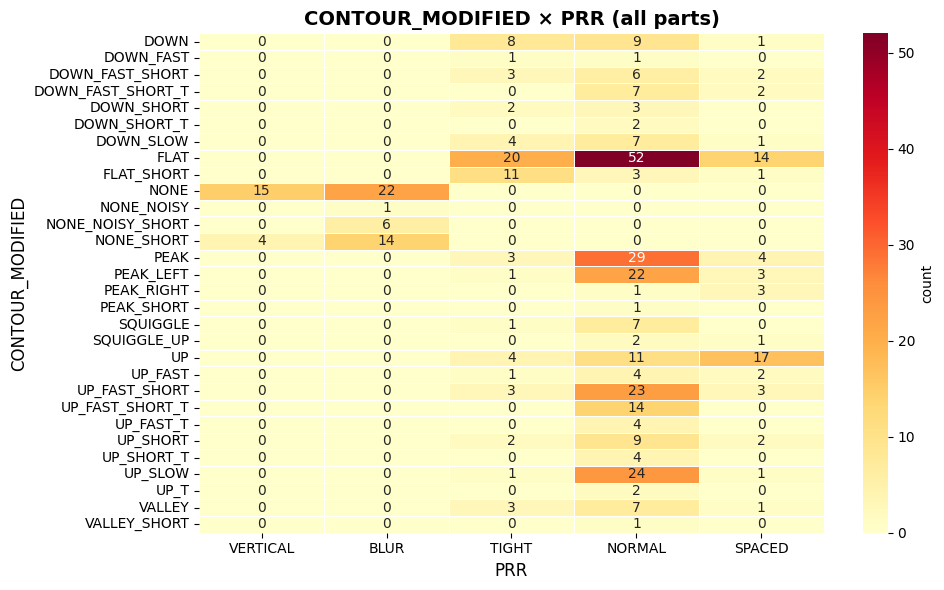

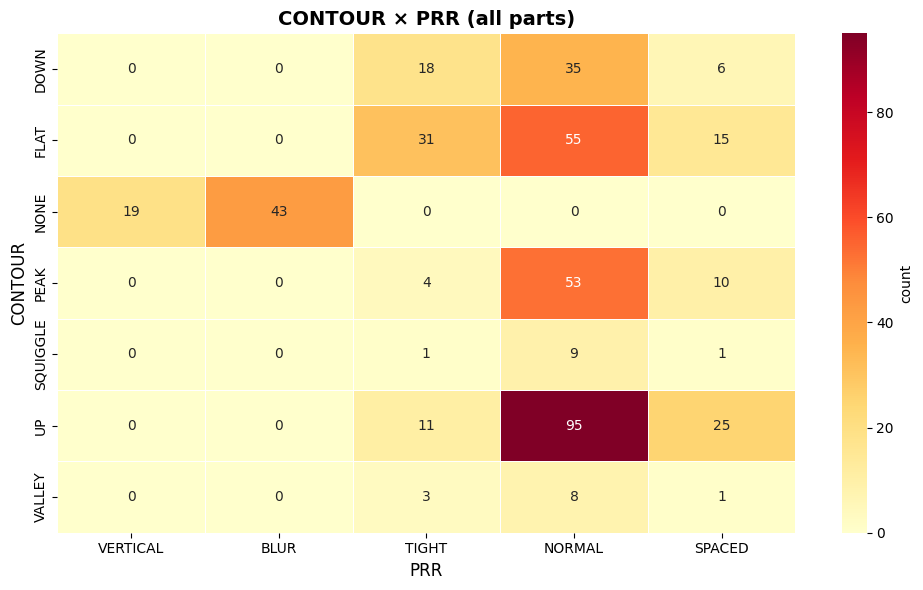

,VERTICAL,BLUR,TIGHT,NORMAL,SPACED
DOWN,0,0,18,35,6
FLAT,0,0,31,55,15
NONE,19,43,0,0,0
PEAK,0,0,4,53,10
SQUIGGLE,0,0,1,9,1
UP,0,0,11,95,25
VALLEY,0,0,3,8,1


In [51]:
# Contour × PRR — all parts
plot_cooccurrence(units_df, 'contour_modified', 'prr')
plot_cooccurrence(units_df, 'contour', 'prr', )


## Analysis: Transition probability matrix

In [52]:
def _get_tokens(unit_row, cat_info):
    """Extract token list from a unit row for a given category."""
    if cat_info['is_list']:
        val = unit_row[cat_info['col']]
        return val if isinstance(val, list) else []
    else:
        val = unit_row[cat_info['col']]
        return [val] if pd.notna(val) else []


def build_transition_pairs(df, category, alt=0, exclude_transitions=False, 
                           between_parts_only=False, add_start_end=False):
    """
    Build a list of (current_token, next_token) pairs by following
    sequential call_unit_idx within each call.
    
    For list-based categories (contour, modifier), each token in the current
    unit is paired with each token in the next unit.
    
    Parameters
    ----------
    df : DataFrame
        The units_df dataframe.
    category : str
        Vocabulary category ('prr', 'contour', 'modifier', 'special').
    alt : int
        Which alternative to use (default 0 = primary).
    exclude_transitions : bool
        If True, filter out units where is_transition == True before 
        building pairs. The next available call_unit_idx is used.
    between_parts_only : bool
        If True, only create pairs between the last unit of one part and
        the first unit of the next part (no within-part transitions).
    add_start_end : bool
        If True, add START → first unit and last unit → END pseudo-transitions.
        When between_parts_only, uses the first unit of the first part and
        the last unit of the last part.
    
    Returns
    -------
    list of (str, str) tuples
    """
    cat_info = CATEGORY_COL_MAP[category]
    
    sub = df[df['part_alternative'] == alt].copy()
    
    if exclude_transitions and 'is_transition' in sub.columns:
        sub = sub[sub['is_transition'] == False]
    
    pairs = []
    
    for filename in sub['filename'].unique():
        call_units = sub[sub['filename'] == filename].sort_values('call_unit_idx')
        
        if call_units.empty:
            continue
        
        if between_parts_only:
            # Group by part, keeping the order of parts by their first call_unit_idx
            parts_in_order = (
                call_units.groupby('part')['call_unit_idx']
                .min()
                .sort_values()
                .index.tolist()
            )
            
            # START → first unit of first part
            if add_start_end and len(parts_in_order) > 0:
                first_part_units = call_units[call_units['part'] == parts_in_order[0]]
                first_unit = first_part_units.loc[first_part_units['call_unit_idx'].idxmin()]
                for t in _get_tokens(first_unit, cat_info):
                    pairs.append(('START', t))
            
            for i in range(len(parts_in_order) - 1):
                curr_part = parts_in_order[i]
                nxt_part = parts_in_order[i + 1]
                
                curr_part_units = call_units[call_units['part'] == curr_part]
                nxt_part_units = call_units[call_units['part'] == nxt_part]
                
                # Last unit of current part, first unit of next part
                last_unit = curr_part_units.loc[curr_part_units['call_unit_idx'].idxmax()]
                first_unit = nxt_part_units.loc[nxt_part_units['call_unit_idx'].idxmin()]
                
                for ct in _get_tokens(last_unit, cat_info):
                    for nt in _get_tokens(first_unit, cat_info):
                        pairs.append((ct, nt))
            
            # Last unit of last part → END
            if add_start_end and len(parts_in_order) > 0:
                last_part_units = call_units[call_units['part'] == parts_in_order[-1]]
                last_unit = last_part_units.loc[last_part_units['call_unit_idx'].idxmax()]
                for t in _get_tokens(last_unit, cat_info):
                    pairs.append((t, 'END'))
        else:
            # START → first unit
            if add_start_end:
                first = call_units.iloc[0]
                for t in _get_tokens(first, cat_info):
                    pairs.append(('START', t))
            
            for i in range(len(call_units) - 1):
                curr = call_units.iloc[i]
                nxt = call_units.iloc[i + 1]
                
                for ct in _get_tokens(curr, cat_info):
                    for nt in _get_tokens(nxt, cat_info):
                        pairs.append((ct, nt))
            
            # Last unit → END
            if add_start_end:
                last = call_units.iloc[-1]
                for t in _get_tokens(last, cat_info):
                    pairs.append((t, 'END'))
    
    return pairs


def plot_transition_matrix(df, category, alt=0, exclude_transitions=False,
                           between_parts_only=False, add_start_end=False,
                           normalize=True, figsize=(10, 8), cmap='YlOrRd', title=None):
    """
    Plot a transition probability matrix for a given vocabulary category.
    
    Shows P(next_token | current_token) as a heatmap.
    
    Parameters
    ----------
    df : DataFrame
        The units_df dataframe.
    category : str
        Vocabulary category ('prr', 'contour', 'modifier', 'special').
    alt : int
        Which alternative to use (default 0).
    exclude_transitions : bool
        If True, exclude transition units before computing.
    between_parts_only : bool
        If True, only transitions between parts (last unit of part → first of next).
    add_start_end : bool
        If True, add START and END pseudo-tokens to see how calls begin/end.
    normalize : bool
        If True, normalize rows to probabilities. If False, show raw counts.
    figsize : tuple
        Figure size.
    cmap : str
        Colormap.
    title : str, optional
        Custom title.
    """
    pairs = build_transition_pairs(df, category, alt=alt, 
                                   exclude_transitions=exclude_transitions,
                                   between_parts_only=between_parts_only,
                                   add_start_end=add_start_end)
    
    if not pairs:
        print("No transition pairs found.")
        return
    
    tokens = list(CATEGORY_COL_MAP[category]['tokens'])
    if add_start_end:
        tokens = ['START'] + tokens + ['END']
    
    # Build count matrix
    count_matrix = pd.DataFrame(0, index=tokens, columns=tokens)
    for curr, nxt in pairs:
        if curr in count_matrix.index and nxt in count_matrix.columns:
            count_matrix.loc[curr, nxt] += 1
    
    # Drop rows/cols that are all zeros
    active = count_matrix.sum(axis=1) + count_matrix.sum(axis=0)
    active_tokens = active[active > 0].index
    count_matrix = count_matrix.loc[active_tokens, active_tokens]
    
    if count_matrix.empty:
        print("No transitions found for this category.")
        return
    
    # Store raw counts for annotation
    annot_matrix = count_matrix.copy()
    
    if normalize:
        prob_matrix = count_matrix.div(count_matrix.sum(axis=1), axis=0).fillna(0)
        display_matrix = prob_matrix
    else:
        display_matrix = count_matrix
    
    # Title
    if title is None:
        flags = []
        if between_parts_only:
            flags.append("between parts only")
        if exclude_transitions:
            flags.append("excl. T units")
        if add_start_end:
            flags.append("with START/END")
        flag_str = f" ({', '.join(flags)})" if flags else ""
        norm_label = "probability" if normalize else "counts"
        title = f"Transition {norm_label}: {category.upper()}{flag_str}"
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Always use normalized values for colors; annotations show probabilities or raw counts
    prob_matrix = count_matrix.div(count_matrix.sum(axis=1), axis=0).fillna(0)
    
    if normalize:
        sns.heatmap(prob_matrix, annot=prob_matrix, fmt='.2f', cmap=cmap,
                    linewidths=0.5, ax=ax, vmin=0, vmax=1,
                    cbar_kws={'label': 'P(next | current)'})
    else:
        sns.heatmap(prob_matrix, annot=annot_matrix, fmt='d', cmap=cmap,
                    linewidths=0.5, ax=ax, vmin=0, vmax=1,
                    cbar_kws={'label': 'P(next | current)'})
    
    ax.set_ylabel('Current unit', fontsize=12)
    ax.set_xlabel('Next unit', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return display_matrix

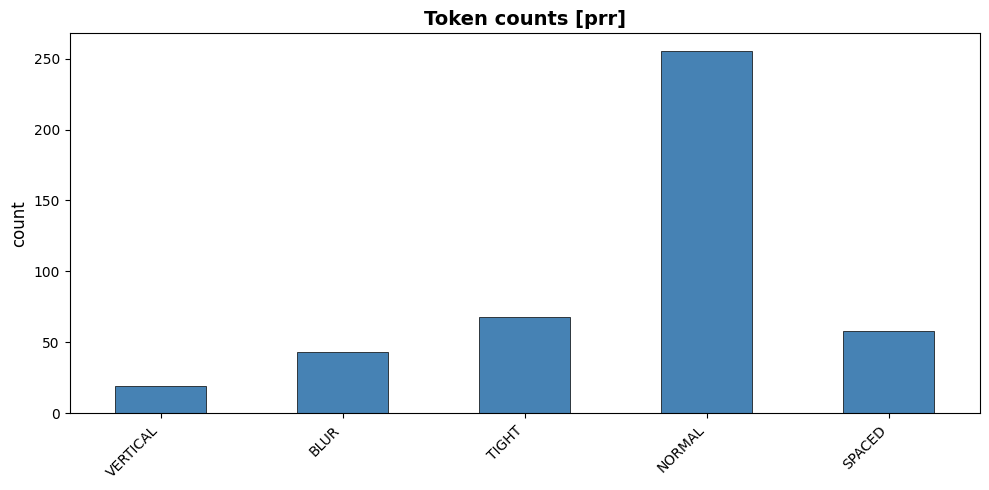

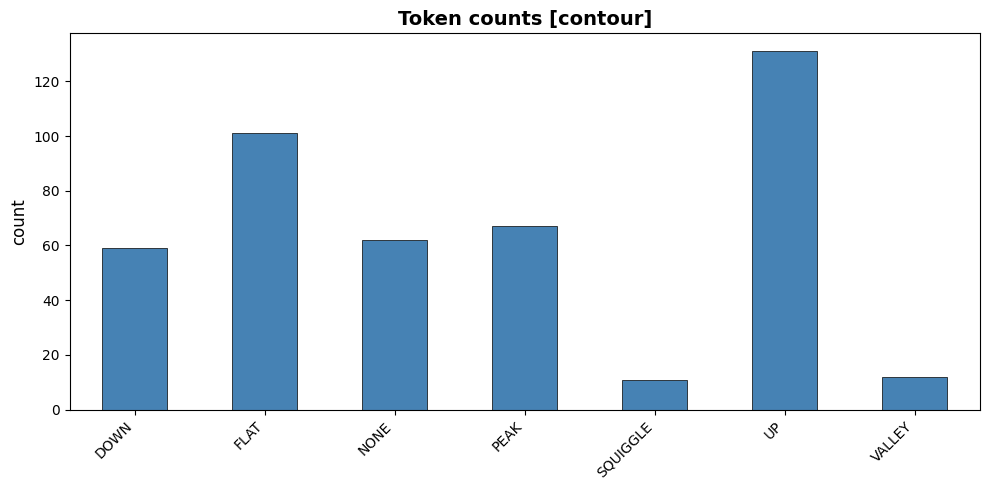

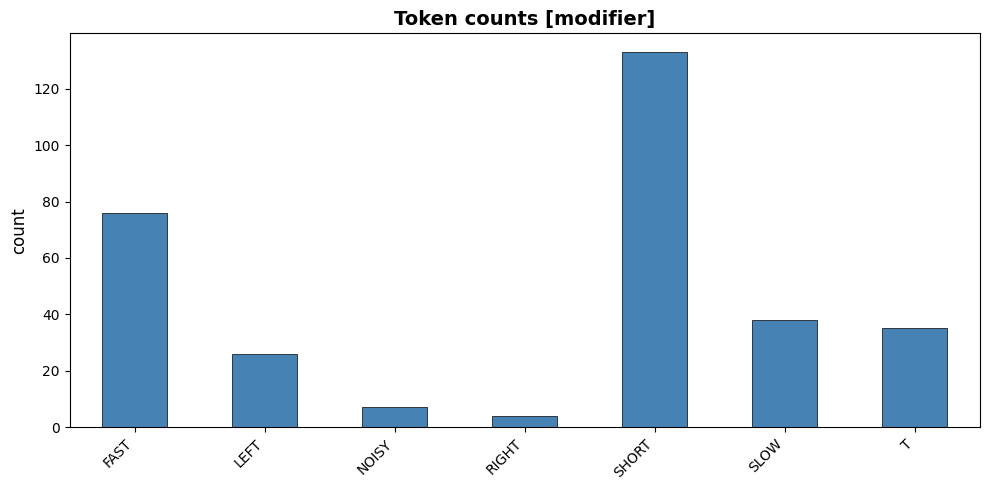

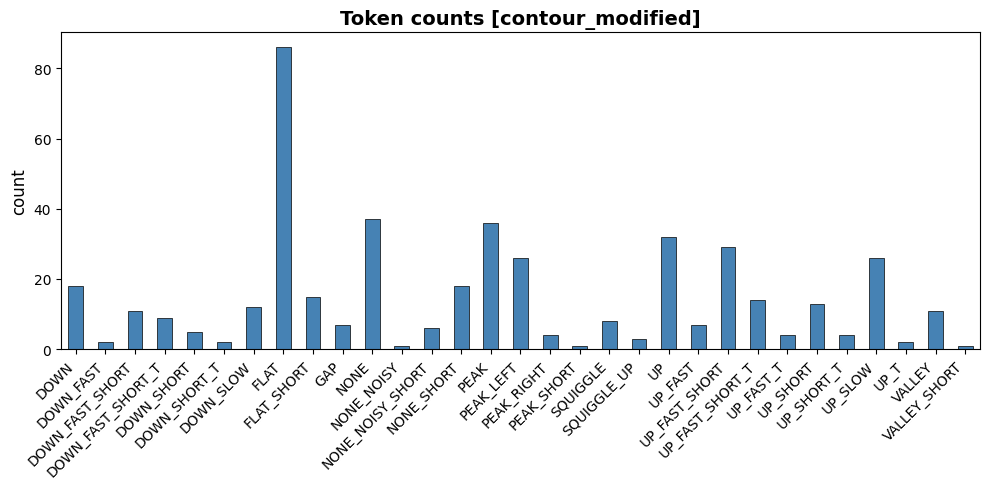

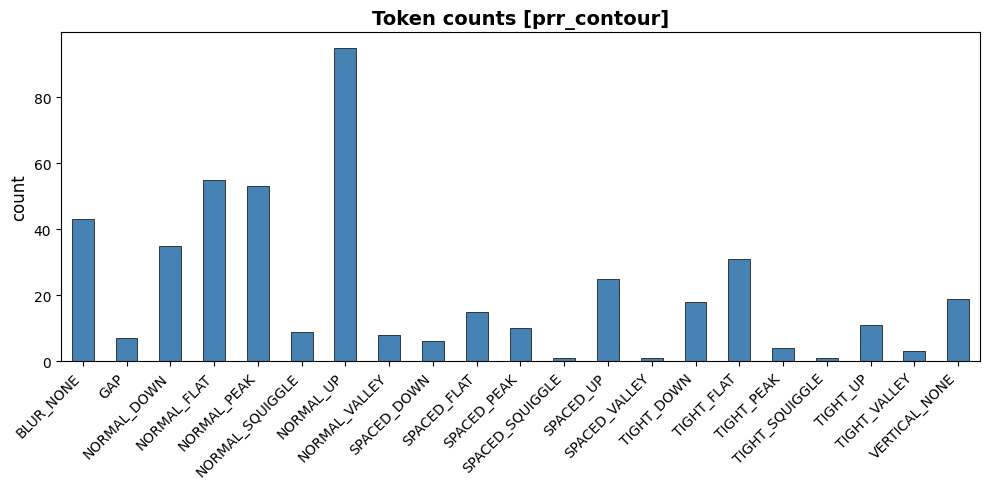

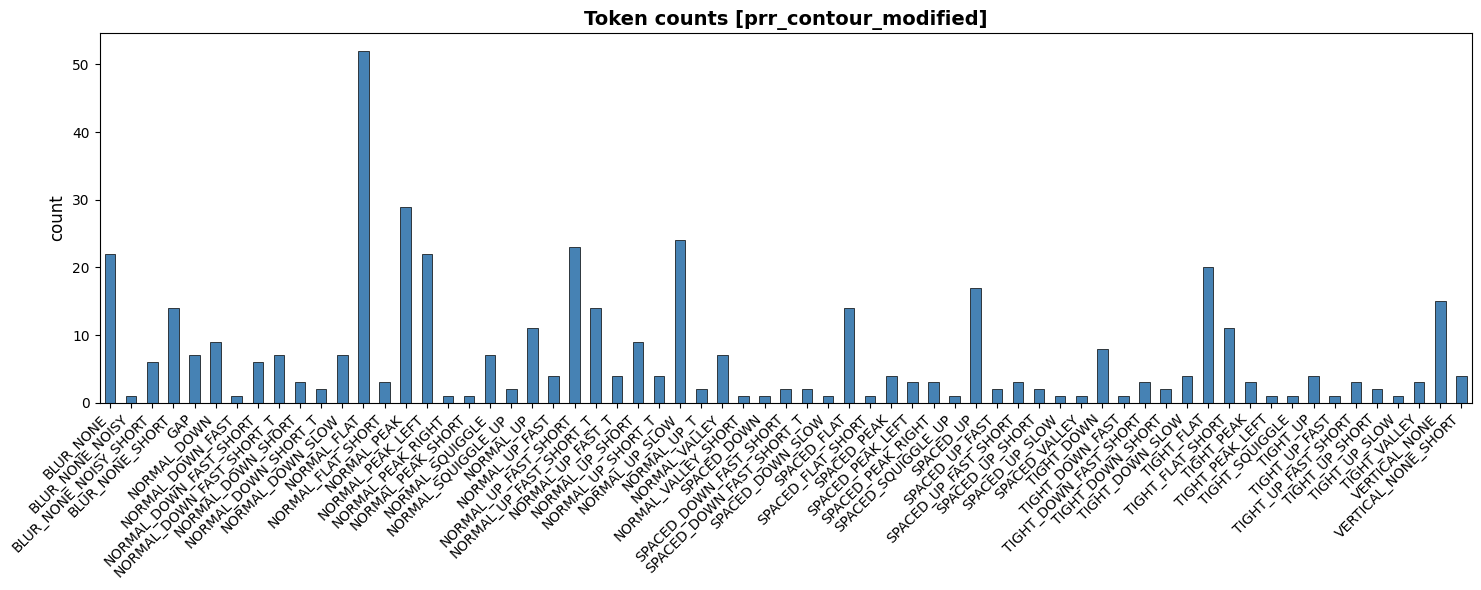

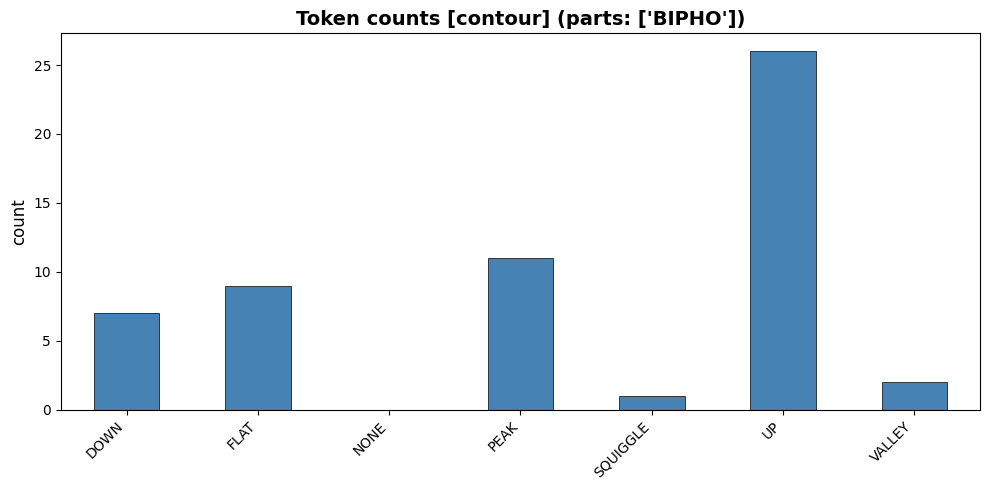

DOWN         7
FLAT         9
NONE         0
PEAK        11
SQUIGGLE     1
UP          26
VALLEY       2
dtype: int64

In [54]:
from collections import Counter

def count_tokens(units_df, filter_part=None, filter_category=None, 
                 normalize=False, plot=False, figsize=(10, 5), title=None):
    """
    Count token occurrences by reading from CATEGORY_COL_MAP columns.
    
    Parameters
    ----------
    units_df : DataFrame
    filter_part : str or list, optional
        Filter to specific parts (e.g. 'BIPHO', ['P1','P2']).
    filter_category : str or list, optional
        Only count tokens from specific vocab categories 
        (e.g. 'prr', 'contour', ['prr', 'modifier']).
    normalize : bool
        If True, return proportions instead of counts.
    plot : bool
        If True, plot results as a bar chart.
    figsize : tuple
        Figure size for the plot.
    title : str, optional
        Custom title for the plot.
    
    Returns
    -------
    pd.Series sorted by count descending.
    """
    sub = units_df
    if filter_part is not None:
        if isinstance(filter_part, str):
            filter_part = [filter_part]
        sub = sub[sub['part'].isin(filter_part)]
    
    # Determine which categories to iterate over
    if filter_category is not None:
        if isinstance(filter_category, str):
            filter_category = [filter_category]
        cats = filter_category
    else:
        cats = list(CATEGORY_COL_MAP.keys())
    
    counter = Counter()
    for cat in cats:
        cat_info = CATEGORY_COL_MAP[cat]
        col = cat_info['col']
        is_list = cat_info['is_list']
        
        for val in sub[col].dropna():
            if is_list:
                items = val if isinstance(val, list) else []
                for item in items:
                    counter[item] += 1
            else:
                counter[val] += 1
    
    # Preserve CATEGORY_COL_MAP ordering when filtering a single category
    if filter_category is not None and len(filter_category) == 1:
        ordered_tokens = [t for t in CATEGORY_COL_MAP[filter_category[0]]['tokens'] if t is not None]
        counts = pd.Series({t: counter.get(t, 0) for t in ordered_tokens})
    else:
        counts = pd.Series(counter).sort_values(ascending=False)
    
    if normalize:
        counts = counts / counts.sum()
    
    if plot:
        fig, ax = plt.subplots(figsize=figsize)
        counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', linewidth=0.5)
        if title is None:
            cat_label = f" [{', '.join(cats)}]" if filter_category else ""
            part_label = f" (parts: {filter_part})" if filter_part else ""
            title = f"Token counts{cat_label}{part_label}"
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_ylabel('proportion' if normalize else 'count', fontsize=12)
        ax.set_xlabel('')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    return counts


# count_tokens(units_df, plot=True)
count_tokens(units_df, filter_category='prr', plot=True)
count_tokens(units_df, filter_category='contour', plot=True)
count_tokens(units_df, filter_category='modifier', plot=True)
count_tokens(units_df, filter_category='contour_modified', plot=True)
count_tokens(units_df, filter_category='prr_contour', plot=True)
count_tokens(units_df, filter_category='prr_contour_modified', plot=True, figsize=(15, 6))
count_tokens(units_df, filter_category='contour', filter_part='BIPHO', plot=True)

In [62]:
units_df["prr_contour"].value_counts(dropna=False)

prr_contour
NORMAL_UP          95
NORMAL_FLAT        55
NORMAL_PEAK        53
BLUR_NONE          43
NORMAL_DOWN        35
TIGHT_FLAT         31
SPACED_UP          25
VERTICAL_NONE      19
TIGHT_DOWN         18
SPACED_FLAT        15
TIGHT_UP           11
SPACED_PEAK        10
NORMAL_SQUIGGLE     9
NORMAL_VALLEY       8
GAP                 7
SPACED_DOWN         6
TIGHT_PEAK          4
TIGHT_VALLEY        3
TIGHT_SQUIGGLE      1
SPACED_VALLEY       1
SPACED_SQUIGGLE     1
Name: count, dtype: int64

In [ ]:
units_df["part"].value_counts()

part
P1       173
P2       154
P3       109
BIPHO     65
P4        30
EXTRA     10
Name: count, dtype: int64

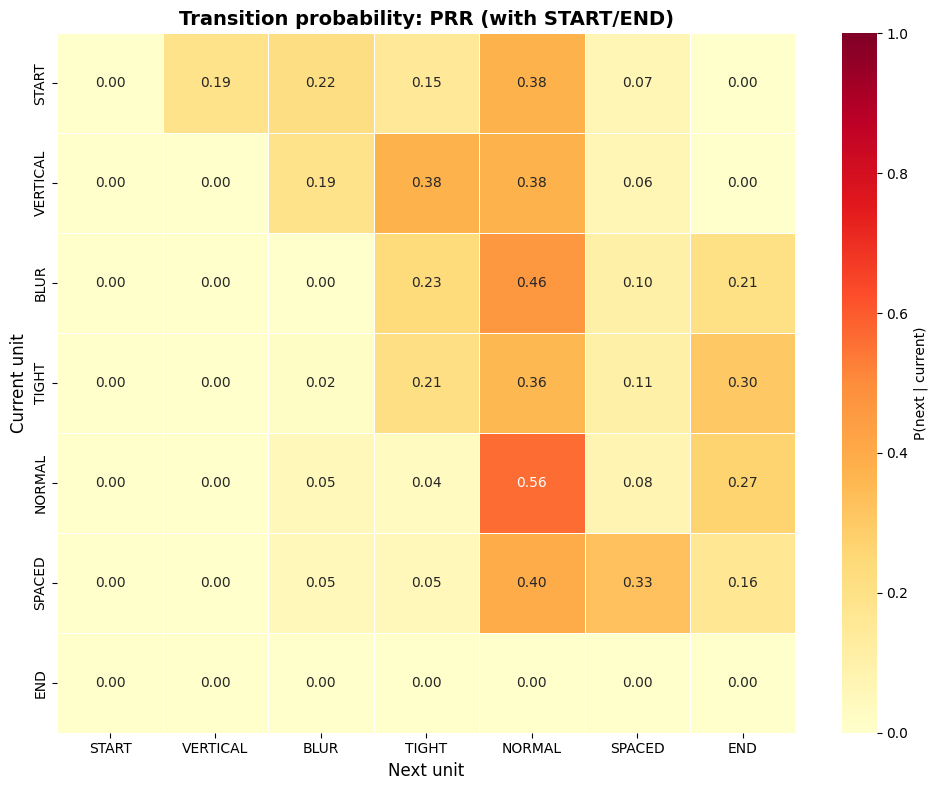

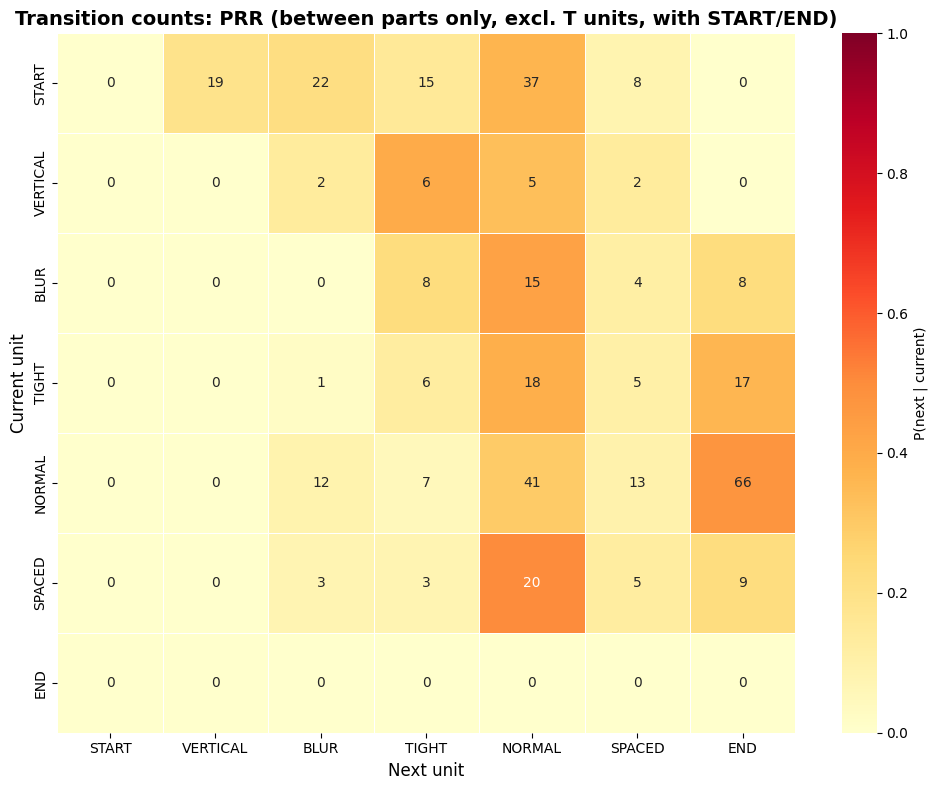

,START,VERTICAL,BLUR,TIGHT,NORMAL,SPACED,END
START,0,19,22,15,37,8,0
VERTICAL,0,0,2,6,5,2,0
BLUR,0,0,0,8,15,4,8
TIGHT,0,0,1,6,18,5,17
NORMAL,0,0,12,7,41,13,66
SPACED,0,0,3,3,20,5,9
END,0,0,0,0,0,0,0


In [57]:
# All unit-to-unit contour transitions
# plot_transition_matrix(units_df, 'contour')

# # Only between-parts: last unit of part → first unit of next part
# plot_transition_matrix(units_df, 'contour', between_parts_only=False, exclude_transitions=True)

# # PRR transitions — all units
# plot_transition_matrix(units_df, 'prr')

# PRR transitions — between parts only
# plot_transition_matrix(units_df, 'prr', between_parts_only=True)

# Between parts, excluding T units
plot_transition_matrix(units_df, 'prr', exclude_transitions=False, add_start_end=True, normalize=True)
plot_transition_matrix(units_df, 'prr', exclude_transitions=True, add_start_end=True, between_parts_only=True, normalize=False)



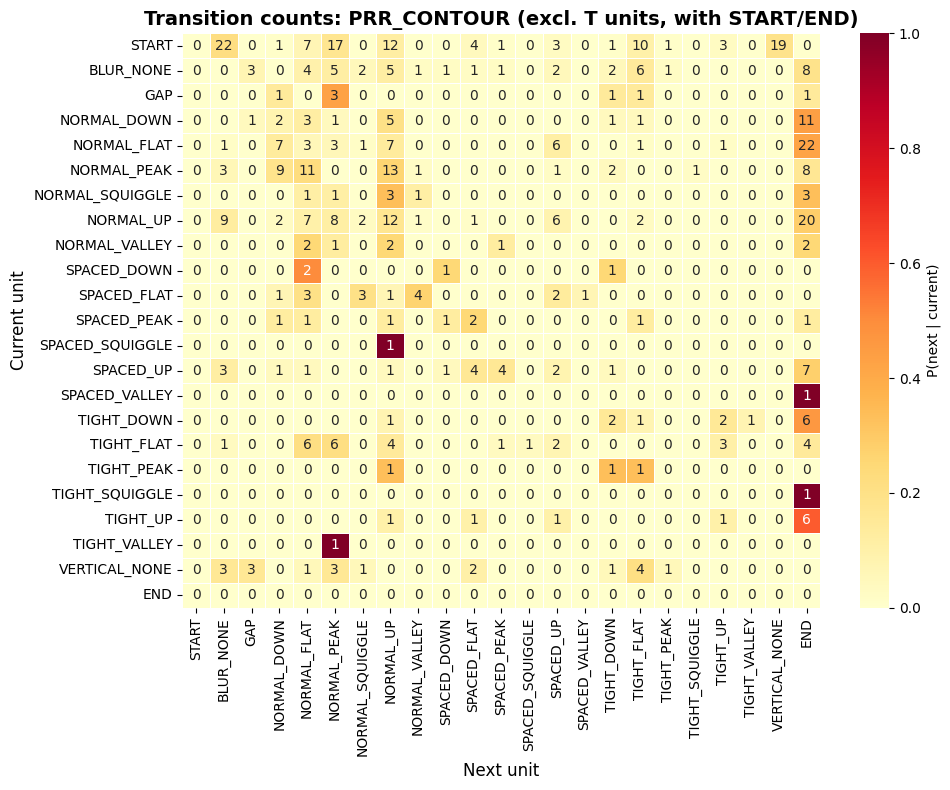

,START,BLUR_NONE,GAP,NORMAL_DOWN,NORMAL_FLAT,NORMAL_PEAK,NORMAL_SQUIGGLE,NORMAL_UP,NORMAL_VALLEY,SPACED_DOWN,SPACED_FLAT,SPACED_PEAK,SPACED_SQUIGGLE,SPACED_UP,SPACED_VALLEY,TIGHT_DOWN,TIGHT_FLAT,TIGHT_PEAK,TIGHT_SQUIGGLE,TIGHT_UP,TIGHT_VALLEY,VERTICAL_NONE,END
START,0,22,0,1,7,17,0,12,0,0,4,1,0,3,0,1,10,1,0,3,0,19,0
BLUR_NONE,0,0,3,0,4,5,2,5,1,1,1,1,0,2,0,2,6,1,0,0,0,0,8
GAP,0,0,0,1,0,3,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1
NORMAL_DOWN,0,0,1,2,3,1,0,5,0,0,0,0,0,0,0,1,1,0,0,0,0,0,11
NORMAL_FLAT,0,1,0,7,3,3,1,7,0,0,0,0,0,6,0,0,1,0,0,1,0,0,22
NORMAL_PEAK,0,3,0,9,11,0,0,13,1,0,0,0,0,1,0,2,0,0,1,0,0,0,8
NORMAL_SQUIGGLE,0,0,0,0,1,1,0,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3
NORMAL_UP,0,9,0,2,7,8,2,12,1,0,1,0,0,6,0,0,2,0,0,0,0,0,20
NORMAL_VALLEY,0,0,0,0,2,1,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
SPACED_DOWN,0,0,0,0,2,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0


In [69]:
plot_transition_matrix(units_df, 'prr_contour', exclude_transitions=True, add_start_end=True, between_parts_only=False, normalize=False)


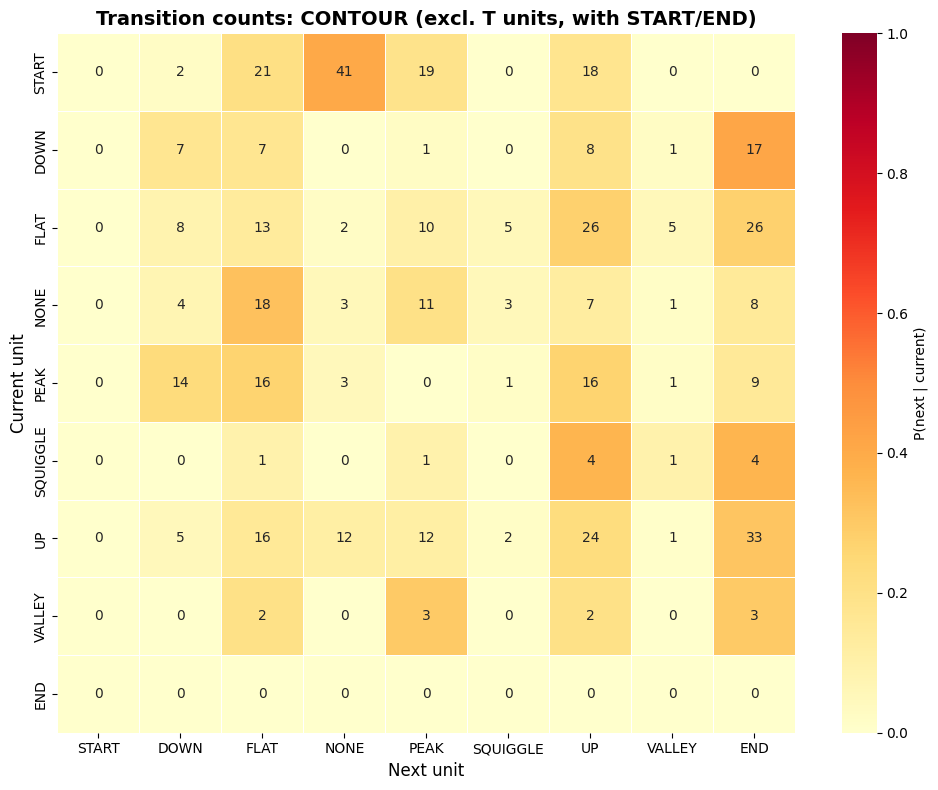

,START,DOWN,FLAT,NONE,PEAK,SQUIGGLE,UP,VALLEY,END
START,0,2,21,41,19,0,18,0,0
DOWN,0,7,7,0,1,0,8,1,17
FLAT,0,8,13,2,10,5,26,5,26
NONE,0,4,18,3,11,3,7,1,8
PEAK,0,14,16,3,0,1,16,1,9
SQUIGGLE,0,0,1,0,1,0,4,1,4
UP,0,5,16,12,12,2,24,1,33
VALLEY,0,0,2,0,3,0,2,0,3
END,0,0,0,0,0,0,0,0,0


In [74]:
plot_transition_matrix(units_df, 'contour', exclude_transitions=True, add_start_end=True, between_parts_only=False, normalize=False)


In [63]:
from token_library.vocab import generate_all_syllables
%load_ext autoreload
%autoreload 2


all_syllables = generate_all_syllables()
print(len(all_syllables))
all_syllables = generate_all_syllables(remove_modifiers=["NOISY"])
all_syllables = generate_all_syllables(remove_modifiers=["SLOW", "FAST", "SHORT", "LEFT", "RIGHT", "NOISY", "T",])
print(len(all_syllables))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
399
27


In [65]:
all_syllables

['GAP',
 'BLUR_NONE',
 'VERTICAL_NONE',
 'NORMAL_UP',
 'NORMAL_DOWN',
 'NORMAL_FLAT',
 'NORMAL_PEAK',
 'NORMAL_VALLEY',
 'NORMAL_SQUIGGLE',
 'NORMAL_SQUIGGLE_UP',
 'NORMAL_SQUIGGLE_DOWN',
 'TIGHT_UP',
 'TIGHT_DOWN',
 'TIGHT_FLAT',
 'TIGHT_PEAK',
 'TIGHT_VALLEY',
 'TIGHT_SQUIGGLE',
 'TIGHT_SQUIGGLE_UP',
 'TIGHT_SQUIGGLE_DOWN',
 'SPACED_UP',
 'SPACED_DOWN',
 'SPACED_FLAT',
 'SPACED_PEAK',
 'SPACED_VALLEY',
 'SPACED_SQUIGGLE',
 'SPACED_SQUIGGLE_UP',
 'SPACED_SQUIGGLE_DOWN']

In [64]:

len(units_df["prr_contour"].unique())

21